# Day 07 — Seismic Attributes using Bruges

## Overview
In this session I explored **seismic attribute analysis using the Bruges Python library**.  
Seismic attributes help highlight geological features such as **faults, stratigraphic boundaries, and reservoir properties**.

For this exercise, a **small subset of the F3 seismic dataset** was used.

Attributes computed:

- Envelope (Reflection Strength / Instantaneous Amplitude)
- Instantaneous Phase
- Instantaneous Frequency
- Similarity (Semblance)
- Window-based attributes

---




In [1]:
import numpy as np 
import bruges as bg


In [ ]:
seismic=np.load()

Opening SEG-Y file...
Number of traces: 112875
Samples per trace: 227
SEG-Y data loaded
Saved: seismic.npy
Loaded shape: (112875, 227)


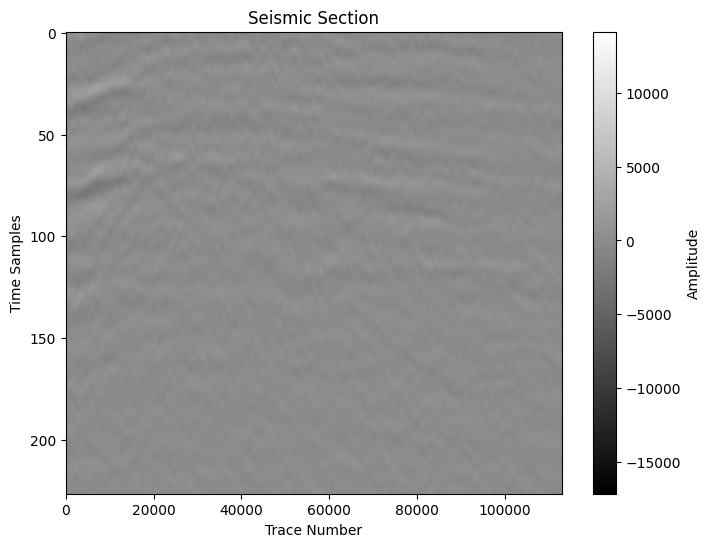

Conversion completed.


In [3]:
# ==========================================
# SEG-Y → NumPy (.npy) Conversion Script
# ==========================================

# Install segyio if not installed
try:
    import segyio
except ImportError:
    !pip install segyio
    import segyio

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Define SEG-Y file path
# -----------------------------
segy_file = "/home/ashraf/Downloads/ST8511r92.segy"   # change this to your SEG-Y file

print("Opening SEG-Y file...")

# -----------------------------
# 2. Load traces
# -----------------------------
with segyio.open(segy_file, "r", ignore_geometry=True) as f:

    n_traces = f.tracecount
    n_samples = len(f.samples)

    print("Number of traces:", n_traces)
    print("Samples per trace:", n_samples)

    # Create empty array
    seismic = np.zeros((n_traces, n_samples))

    # Read traces
    for i in range(n_traces):
        seismic[i] = f.trace[i]

print("SEG-Y data loaded")

# -----------------------------
# 3. Save NumPy file
# -----------------------------
output_file = "seismic.npy"

np.save(output_file, seismic)

print("Saved:", output_file)

# -----------------------------
# 4. Verify saved file
# -----------------------------
seismic_loaded = np.load(output_file)

print("Loaded shape:", seismic_loaded.shape)

# -----------------------------
# 5. Plot seismic section
# -----------------------------
plt.figure(figsize=(8,6))

plt.imshow(seismic_loaded.T,
           cmap="gray",
           aspect="auto")

plt.title("Seismic Section")
plt.xlabel("Trace Number")
plt.ylabel("Time Samples")

plt.colorbar(label="Amplitude")

plt.show()

print("Conversion completed.")


In [2]:
import numpy as np 
seismic_npy=np.load("/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/Data/156_iline.npy")
seismic_npy.shape

(227, 301)

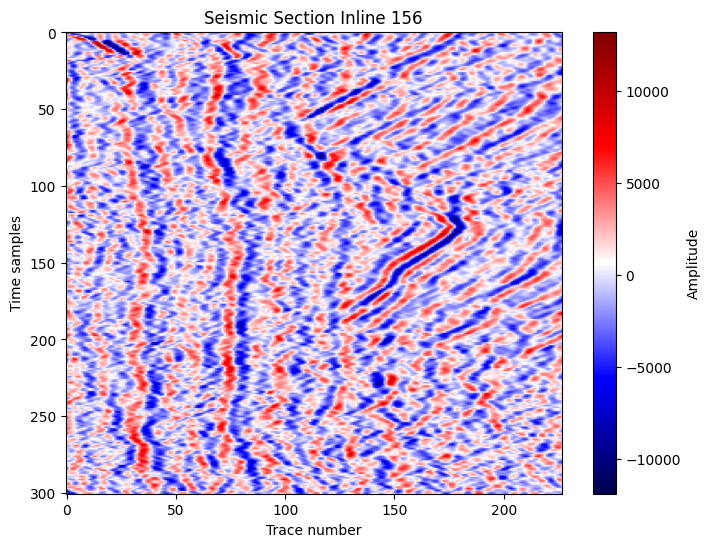

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(seismic_npy.T,
           cmap="seismic",
           aspect="auto")

plt.xlabel("Trace number")
plt.ylabel("Time samples")
plt.title("Seismic Section Inline 156")

plt.colorbar(label="Amplitude")

plt.show()


# Complex trace attributes

# What is the Envelope Attribute?

The **Envelope** represents the **instantaneous amplitude of a seismic signal**.

Instead of looking at positive and negative oscillations of the seismic trace, the envelope captures the **overall signal energy at each time sample**.

###  (Mathematical Definition)

Mathematically, if a seismic trace is:

$$
s(t)
$$

and its **Hilbert Transform** is:

$$
\hat{s}(t)
$$

then the **Envelope** is given by:

$$
Envelope(t) = \sqrt{s(t)^2 + \hat{s}(t)^2}
$$

Where:

- **$s(t)$** → Original seismic trace  
- **$\hat{s}(t)$** → Hilbert transform of the trace  

The envelope is **always positive**, making it easier to interpret reflection strength.

---

# Why Envelope Attribute is Important

The envelope attribute is widely used in **seismic interpretation workflows** because it highlights **reflection energy**.

It is useful for identifying:

- **Bright spots** (possible hydrocarbon indicators)
- **Fault zones**
- **Stratigraphic channels**
- **Thin-bed reflections**
- **Reservoir boundaries**

Compared to raw seismic amplitude, the envelope makes **strong reflectors more visible**.

---



In [20]:
import bruges as bg
# Envelope attribute
env=bg.attribute.envelope(seismic_npy)
print("Shape of the seismic file:",seismic_npy.shape)
print("Shape of the envelope attribute:",env.shape)
print(env[5].shape)

Shape of the seismic file: (227, 301)
Shape of the envelope attribute: (227, 301)
(301,)


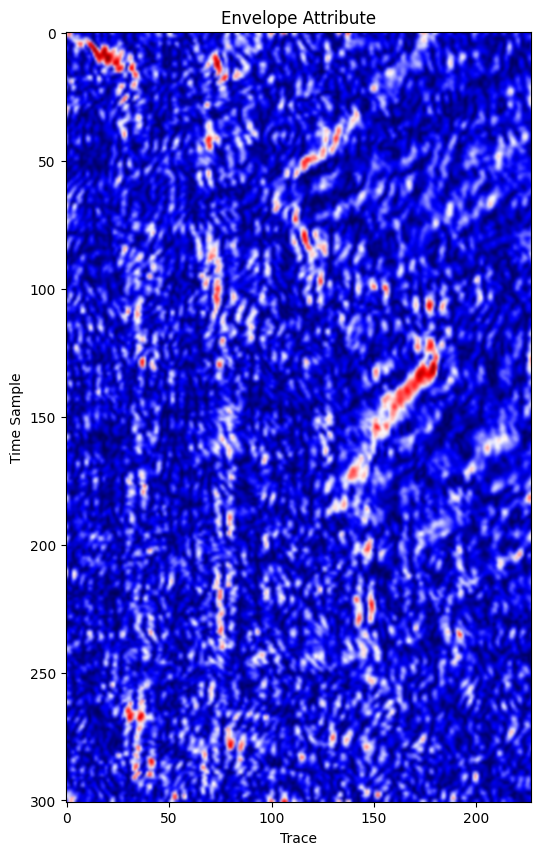

In [21]:
plt.figure(figsize=(6,10))
plt.imshow(env.T, cmap="seismic", aspect="auto", interpolation="bicubic")
plt.title("Envelope Attribute")
plt.xlabel("Trace")
plt.ylabel("Time Sample")
plt.show()

Text(0, 0.5, 'Amplitude')

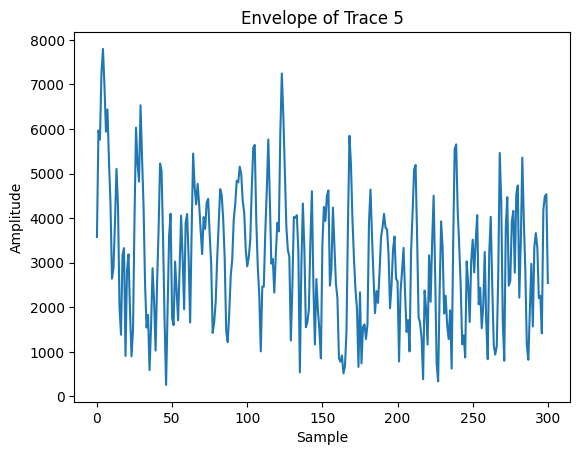

In [22]:
plt.plot(env[5])
plt.title("Envelope of Trace 5")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

# Instantaneous phase

## Instantaneous Phase (Seismic Attribute)

![Image](https://www.researchgate.net/publication/361408366/figure/fig4/AS%3A11431281110829865%401672761265826/nstantaneous-phase-attribute-section-passing-through-well-Du-2.jpg)

![Image](https://www.researchgate.net/publication/341528574/figure/fig1/AS%3A11431281078949299%401660396995768/Seismic-instantaneous-phase-attribute-equivalent-to-the-seismic-slice-shown-in-Fig-2.png)

![Image](https://www.beg.utexas.edu/lmod/mod04/graphics/9926.gif)

![Image](https://www.beg.utexas.edu/lmod/mod04/graphics/9927.gif)

**Instantaneous Phase** is a seismic attribute that describes the **phase angle of the seismic signal at every sample**.  
Unlike amplitude-based attributes, it focuses on **waveform geometry and reflector continuity** rather than signal strength.

It is computed using the **Hilbert transform** of the seismic trace.

---

### Mathematical Definition

If a seismic trace is

$$
s(t)
$$

and its Hilbert transform is

$$
\hat{s}(t)
$$

then the **instantaneous phase** is

$$
\phi(t) = \tan^{-1}\left(\frac{\hat{s}(t)}{s(t)}\right)
$$

Where:

- **$s(t)$** → original seismic trace  
- **$\hat{s}(t)$** → Hilbert transform  
- **$\phi(t)$** → instantaneous phase

The phase value typically ranges from

$$
-180^\circ \; \text{to} \; +180^\circ
$$

---

### Why It Is Useful

Geophysicists use instantaneous phase because it **removes amplitude variations** and highlights **continuous reflectors and structural features**.

Common applications:

- Horizon tracking  
- Fault interpretation  
- Stratigraphic analysis  
- Thin-bed detection

---

### Python Example (Bruges)

```python
import bruges as bg
import matplotlib.pyplot as plt

phase = bg.attribute.instantaneous_phase(seismic_npy)

plt.figure(figsize=(6,10))
plt.imshow(phase[5].T, cmap="twilight", aspect="auto")
plt.title("Instantaneous Phase")
plt.show()

In [25]:
inst_phase = bg.attribute.instantaneous_phase(seismic_npy)
inst_phase.shape


(227, 301)

/tmp/ipykernel_53544/2525037410.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


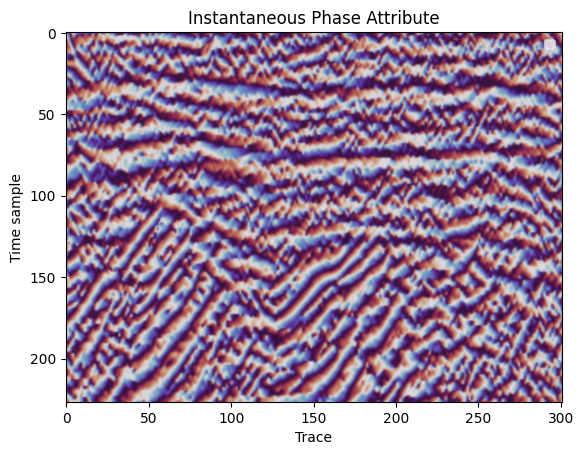

In [32]:
plt.Figure(figsize=(10,8))
plt.imshow(inst_phase,interpolation="bicubic",aspect="auto",cmap="twilight")
plt.title("Instantaneous Phase Attribute")
plt.xlabel("Trace")
plt.ylabel("Time sample")
plt.legend()

# 📡 Instantaneous Frequency
### Seismic Attribute | 100 Days Python — Oil & Gas

> **Category:** Instantaneous Attribute  
> **Derived from:** Instantaneous Phase → Hilbert Transform  
> **Use case:** Thin-bed detection · Hydrocarbon indicators · Stratigraphic analysis

---

## 🔷 What is Instantaneous Frequency?

**Instantaneous Frequency** is a seismic attribute that measures the **rate of change of instantaneous phase with respect to time** — in other words, *how fast the phase of the seismic signal is evolving at every single time sample*.

Unlike conventional frequency (which is a single number describing an entire signal), instantaneous frequency gives a **frequency value at every point** along the trace — making it a dynamic, time-varying measure.

```
Seismic Trace s(t)
       │
       ▼
  Hilbert Transform
       │
       ▼
  Analytic Signal: A(t) = s(t) + i·ŝ(t)
       │
       ▼
  Instantaneous Phase: φ(t) = arctan[ ŝ(t) / s(t) ]
       │
       ▼
  Instantaneous Frequency: f(t) = (1/2π) · dφ(t)/dt   ◄── THIS ATTRIBUTE
```

> 💡 **Analogy:** Think of a radio signal. Instantaneous frequency is like the FM dial reading changing in real time — instead of one fixed frequency, you get a continuous frequency "readout" as the signal evolves.

---

## 🔷 Why is it Useful?

Raw seismic amplitude alone cannot always reveal everything about the subsurface. Instantaneous frequency fills in the gaps by being sensitive to things that *amplitude is blind to*.

| Geological Feature | How Instantaneous Frequency Responds |
|---|---|
| **Thin beds** | Frequency drops near the tuning thickness |
| **Gas / Hydrocarbon zones** | Low-frequency anomalies ("low-freq shadow") |
| **Stratigraphic boundaries** | Abrupt frequency changes at layer interfaces |
| **Channel bodies** | Distinct frequency texture compared to surrounding shale |
| **Attenuation zones** | Progressive frequency loss downdip |
| **Fractures & faults** | Frequency discontinuities |

> 🛢️ **Key insight:** Hydrocarbons — especially gas — cause **seismic attenuation**, which preferentially absorbs **high frequencies**. This leaves behind a low-frequency anomaly directly below a reservoir, known as a **"low-frequency shadow"**. Instantaneous frequency can detect this.

---

## 🔷 Mathematical Foundation

### Step 1 — Build the Analytic Signal

Starting from the real seismic trace $s(t)$, we construct the **analytic signal** using the Hilbert transform $\mathcal{H}$:

$$
A(t) = s(t) + i\,\hat{s}(t)
$$

where:

$$
\hat{s}(t) = \mathcal{H}\{s(t)\} = \frac{1}{\pi} \, \text{P.V.} \int_{-\infty}^{\infty} \frac{s(\tau)}{t - \tau} \, d\tau
$$

- $s(t)$ → real part (original trace)
- $\hat{s}(t)$ → imaginary part (quadrature trace, 90° phase-shifted)
- P.V. → Cauchy principal value of the integral

---

### Step 2 — Extract Instantaneous Phase

The **instantaneous phase** $\phi(t)$ is the angle of the analytic signal in the complex plane:

$$
\phi(t) = \arctan\!\left(\frac{\hat{s}(t)}{s(t)}\right) = \arg\!\left[A(t)\right]
$$

> ⚠️ In practice, `np.unwrap()` is applied to $\phi(t)$ to remove artificial $2\pi$ discontinuities and produce a smooth, continuous phase signal.

---

### Step 3 — Compute Instantaneous Frequency

**Instantaneous frequency** $f(t)$ is the time derivative of the unwrapped phase:

$$
\boxed{f(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}}
$$

Where:

| Symbol | Meaning |
|---|---|
| $f(t)$ | Instantaneous frequency (Hz) — varies with time |
| $\phi(t)$ | Instantaneous phase (radians) |
| $\dfrac{d\phi(t)}{dt}$ | Rate of phase change with time |
| $\dfrac{1}{2\pi}$ | Converts angular frequency (rad/s) → frequency (Hz) |

In discrete form (as implemented in Python):

$$
f[n] = \frac{\phi[n+1] - \phi[n]}{2\pi \cdot \Delta t}
$$

where $\Delta t$ is the sample interval in seconds.

---

### Summary: Three Attributes from One Transform

$$
A(t) = \underbrace{\sqrt{s(t)^2 + \hat{s}(t)^2}}_{\text{Envelope}} \cdot e^{\,i\,\underbrace{\arctan\!\left(\hat{s}/s\right)}_{\text{Inst. Phase}}}
\quad\Longrightarrow\quad
\underbrace{\frac{d\phi}{dt} \cdot \frac{1}{2\pi}}_{\text{Inst. Frequency}}
$$

---

## 🔷 Visual Interpretation

```
Seismic Trace:
     ╭──╮       ╭────╮       ╭──╮
────/    \─────/      \─────/    \──────►  time
           \/          \/

Instantaneous Phase (unwrapped):
    ╱         ╱         ╱
───╱─────────╱─────────╱──────────────►  time
  (ramps up continuously, slope = 2π·f)

Instantaneous Frequency:
──────────── flat ────────────────────►  stable zone
   ↓ spike at zero-crossings of trace
   ↓ drops in gas/attenuation zones
   ↓ noisy where envelope is near zero  ← unreliable here!
```

> ⚠️ **Reliability note:** Instantaneous frequency becomes **unstable and noisy** where the **envelope (reflection strength) is near zero**. Always interpret it alongside the envelope — if the envelope is low, the frequency value is unreliable.

---

## 🔷 Python Implementation

### Option A — Manual (NumPy + SciPy)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def instantaneous_frequency(trace: np.ndarray, dt: float = 0.002) -> np.ndarray:
    """
    Compute instantaneous frequency of a 1D seismic trace.

    Parameters
    ----------
    trace : np.ndarray
        1D array — seismic amplitude values
    dt : float
        Sample interval in seconds (default: 0.002 s = 2 ms)

    Returns
    -------
    inst_freq : np.ndarray
        Instantaneous frequency in Hz (length = len(trace) - 1)
    """
    analytic   = hilbert(trace)                        # Complex trace
    phase      = np.unwrap(np.angle(analytic))         # Unwrapped phase φ(t)
    inst_freq  = np.diff(phase) / (2.0 * np.pi * dt)  # f(t) = dφ/dt / 2π

    return inst_freq


# ── Demo: Ricker wavelet ──────────────────────────────────────────────────────
def ricker(f: float = 30, dt: float = 0.002, duration: float = 0.3) -> tuple:
    t = np.arange(-duration / 2, duration / 2, dt)
    psi = (1 - 2 * (np.pi * f * t) ** 2) * np.exp(-(np.pi * f * t) ** 2)
    return t, psi

t, trace = ricker(f=30, dt=0.002)

analytic  = hilbert(trace)
envelope  = np.abs(analytic)
phase     = np.unwrap(np.angle(analytic))
inst_freq = instantaneous_frequency(trace, dt=0.002)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
fig.suptitle("Instantaneous Frequency — Seismic Attribute", fontsize=15, fontweight="bold")

axes[0].plot(t, trace, color="#1f77b4", lw=1.8, label="Seismic Trace")
axes[0].fill_between(t, trace, alpha=0.15, color="#1f77b4")
axes[0].axhline(0, color="gray", lw=0.5, ls="--")
axes[0].set_ylabel("Amplitude"); axes[0].legend(loc="upper right")
axes[0].set_title("① Raw Seismic Trace s(t)")

axes[1].plot(t, envelope, color="#ff7f0e", lw=1.8, label="Envelope |A(t)|")
axes[1].set_ylabel("Envelope"); axes[1].legend(loc="upper right")
axes[1].set_title("② Envelope (Reflection Strength) — reliability mask for Inst. Freq")

axes[2].plot(t, phase, color="#2ca02c", lw=1.8, label="Unwrapped Phase φ(t)")
axes[2].set_ylabel("Phase (rad)"); axes[2].legend(loc="upper right")
axes[2].set_title("③ Instantaneous Phase — slope = 2π·f(t)")

axes[3].plot(t[:-1], inst_freq, color="#d62728", lw=1.8, label="Inst. Frequency f(t)")
axes[3].axhline(30, color="k", lw=1.0, ls="--", alpha=0.5, label="True wavelet freq (30 Hz)")
axes[3].set_ylabel("Frequency (Hz)"); axes[3].set_xlabel("Time (s)")
axes[3].legend(loc="upper right")
axes[3].set_title("④ Instantaneous Frequency f(t) = (1/2π) · dφ/dt")

plt.tight_layout()
plt.savefig("instantaneous_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
```

---

### Option B — Using `bruges` Library

```python
import numpy as np
import bruges as bg
import matplotlib.pyplot as plt

# seismic_npy: shape (inlines, crosslines, samples)
# e.g. loaded from a SEG-Y file using segysak or segyio

freq = bg.attribute.instantaneous_frequency(seismic_npy)

# Plot a single inline slice
plt.figure(figsize=(6, 10))
plt.imshow(
    freq[5].T,          # inline index 5, transposed for correct orientation
    cmap="viridis",
    aspect="auto",
    vmin=0, vmax=80     # clip to geologically meaningful range
)
plt.colorbar(label="Frequency (Hz)")
plt.title("Instantaneous Frequency — Inline 5", fontsize=13)
plt.xlabel("Crossline"); plt.ylabel("TWT (samples)")
plt.tight_layout()
plt.show()
```

> 📦 **Install bruges:** `pip install bruges`  
> 📦 **Install segysak (for SEG-Y loading):** `pip install segysak`

---

## 🔷 Interpretation Guide

```
Instantaneous Frequency Map — What to Look For
─────────────────────────────────────────────────────────────
  HIGH frequency zone  │  Tight, well-compacted shale / carbonates
  LOW frequency zone   │  Gas sand, poorly consolidated sediment,
                       │  or tuning effect near thin beds
  Frequency spike      │  Noise — typically at zero-crossings;
                       │  always check envelope before trusting
  Abrupt lateral change│  Stratigraphic boundary, fault plane
─────────────────────────────────────────────────────────────
```

---

## 🔷 Common Pitfalls

| Issue | Cause | Fix |
|---|---|---|
| Extreme spikes | Low envelope (near zero crossing) | Mask with envelope threshold |
| Negative frequency | Phase unwrapping error | Apply `np.unwrap()` properly |
| Noisy output | No smoothing applied | Apply Gaussian or median filter |
| Unrealistic values | No clipping | Clip to $[0, f_{Nyquist}]$ |

```python
# Best practice: mask by envelope before display
threshold = 0.1 * envelope.max()
inst_freq_masked = np.where(envelope[:-1] > threshold, inst_freq, np.nan)
```

---

## 🔷 Quick Reference

$$
\underbrace{s(t)}_{\text{trace}} 
\xrightarrow{\mathcal{H}} 
\underbrace{A(t) = s(t) + i\hat{s}(t)}_{\text{analytic signal}}
\xrightarrow{\arg(\cdot)} 
\underbrace{\phi(t)}_{\text{inst. phase}}
\xrightarrow{\tfrac{d}{dt} \cdot \tfrac{1}{2\pi}} 
\underbrace{f(t)}_{\text{inst. frequency}}
$$

---

## 📚 References

- Taner, M. T., Koehler, F., & Sheriff, R. E. (1979). *Complex seismic trace analysis.* **Geophysics**, 44(6), 1041–1063.
- Barnes, A. E. (1993). *Instantaneous spectral bandwidth and dominant frequency with applications to seismic reflection data.* **Geophysics**, 58(3), 419–428.
- Chopra, S., & Marfurt, K. J. (2007). *Seismic Attributes for Prospect Identification and Reservoir Characterization.* SEG Geophysical Developments Series.

---

*Part of the **#100DaysPython Oil & Gas** Challenge · Seismic Attributes Series*

In [36]:
inst_freq=bg.attribute.instantaneous_frequency(seismic_npy,dt=0.004)
print("shape of the instantaneous frequency:,",inst_freq.shape)

shape of the instantaneous frequency:, (226, 301)


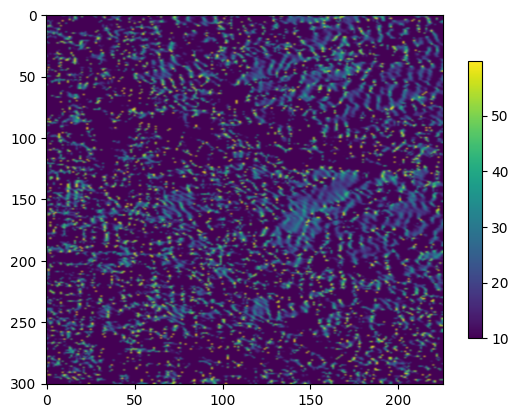

In [44]:
plt.imshow(inst_freq.T,interpolation="bicubic",aspect="auto",vmin=10)
plt.colorbar(shrink=0.75)

# 🛢️ Similarity & Discontinuity Attributes
### Seismic Attribute Family | 100 Days Python — Oil & Gas

> **Family:** Multi-Trace Geometric Attributes  
> **Members:** Similarity · Coherence · Semblance · Variance · Eigenstructure · Gradient Structure Tensor (GST)  
> **Use case:** Fault detection · Channel mapping · Stratigraphic boundary delineation · Fracture characterization

---

## 📌 Table of Contents
- [What is Similarity?](#what)
- [Why Is It Used?](#why)
- [How Is It Computed? (The Family Tree)](#how)
  - [C1 — Cross-Correlation Coherence (Bahorich & Farmer, 1995)](#c1)
  - [C2 — Semblance-Based Coherence (Marfurt et al., 1998)](#c2)
  - [C3 — Eigenstructure Coherence (Gersztenkorn & Marfurt, 1999)](#c3)
  - [Variance](#variance)
  - [Gradient Structure Tensor (GST)](#gst)
- [Visual Comparison](#viz)
- [Python Implementation](#code)
- [Interpretation Guide](#interpret)
- [Pitfalls](#pitfalls)
- [Summary Table](#summary)

---

<a name="what"></a>
## 🔷 1. What is Similarity?

**Similarity** (also called **coherence**, **semblance**, or **discontinuity**) is a family of **multi-trace seismic attributes** that measure **how alike neighbouring seismic traces are** within a local analysis window.

```
    Trace i-1    Trace i    Trace i+1
        │            │            │
   ╭────┤       ╭────┤       ╭────┤
   │    │       │    │       │    │
   │    │       │    │       │    │   ← Analysis Window
   │    │       │    │       │    │     (time + spatial)
   ╰────┤       ╰────┤       ╰────┤
        │            │            │
        └────────────┴────────────┘
               ↓ Compare ↓
        HIGH similarity → continuous reflector
        LOW  similarity → fault / edge / channel boundary
```

> 💡 **Core idea:** Where the earth is uniform and layered, adjacent traces look alike (high coherence). Where something interrupts that layering — a fault, a channel edge, a reef boundary — the traces look different (low coherence). The attribute **maps those differences**.

> ⚠️ **Terminology note:** "Coherence", "semblance", "similarity", and "discontinuity" all refer to the same *family* of attributes. Different software vendors use different names. The algorithms differ slightly — but the concept is identical.

---

<a name="why"></a>
## 🔷 2. Why Is It Used?

Raw amplitude seismic sections show reflectors well but are poor at showing **where reflectors stop** — which is exactly where the interesting geology is.

![Coherence slice showing faults and fractures clearly — Cook Inlet, Alaska](https://csegrecorder.com/assets/images/articles/archive/2001-12-cube-imaging-fig01.jpg)
*Fig 1: Coherence time slice (right) vs. seismic amplitude time slice (left). Faults and fractured zones invisible on amplitude are clearly delineated on the coherence slice. Cook Inlet, Alaska. (Chopra & Pickford, CSEG Recorder, 2001)*

| Geological Target | Why Similarity Works |
|---|---|
| **Faults** | Displaced strata create waveform mismatch between traces |
| **Channels** | Channel margins = abrupt lateral waveform changes |
| **Reefs / carbonate mounds** | Hard boundaries produce sharp coherence edges |
| **Mass-transport deposits (MTDs)** | Chaotic internal reflectors → very low coherence |
| **Fracture corridors** | Densely fractured rock scatters energy differently |
| **Salt body edges** | Dramatic impedance contrast at the salt flank |
| **Stratigraphic pinchouts** | Lateral thickness changes alter waveform character |

![Reef boundaries seen distinctly on coherence slice](https://csegrecorder.com/assets/images/articles/archive/2001-12-cube-imaging-fig02.jpg)
*Fig 2: Reef boundaries stand out sharply as coherence edges. (Chopra & Pickford, CSEG Recorder, 2001)*

![Channel bodies clearly visible on coherence slice](https://csegrecorder.com/assets/images/articles/archive/2001-12-cube-imaging-fig03.jpg)
*Fig 3: Channel bodies and their lateral boundaries mapped clearly using coherence. (Chopra & Pickford, CSEG Recorder, 2001)*

---

<a name="how"></a>
## 🔷 3. How Is It Computed? — The Family Tree

```
SIMILARITY / DISCONTINUITY ATTRIBUTE FAMILY
│
├── C1: Cross-Correlation Coherence    (Bahorich & Farmer, 1995)
│        3-trace, amplitude-sensitive
│
├── C2: Semblance-Based Coherence      (Marfurt et al., 1998)
│        N-trace, amplitude-sensitive
│
├── C3: Eigenstructure Coherence       (Gersztenkorn & Marfurt, 1999)
│        N-trace, waveform-only (amplitude-insensitive)
│
├── Variance                           (related to 1 − Semblance)
│        Highlights discontinuities directly
│
└── Gradient Structure Tensor (GST)    (Randen et al., 2000)
         Measures how gradients co-vary locally
         → dip, azimuth, and planarity attributes
```

---

<a name="c1"></a>
### 3.1 C1 — Cross-Correlation Coherence *(Bahorich & Farmer, 1995)*

The **first generation** coherence algorithm. Uses the **normalised cross-correlation** of just 3 traces — one inline pair and one crossline pair — at zero lag.

$$
C_1 = \sqrt{ \rho_{xy}^2 \cdot \rho_{xz}^2 }
$$

Where $\rho_{xy}$ is the **normalised cross-correlation** between trace $x$ (centre) and trace $y$ (inline neighbour):

$$
\rho_{xy} = \frac{ \displaystyle\sum_{k=-K}^{K} s_x(t_k)\, s_y(t_k) }
                 { \sqrt{ \displaystyle\sum_{k=-K}^{K} s_x^2(t_k) \cdot \displaystyle\sum_{k=-K}^{K} s_y^2(t_k) } }
$$

Where:

| Symbol | Meaning |
|---|---|
| $s_x(t_k)$ | Amplitude of central trace at sample $k$ |
| $s_y(t_k)$ | Amplitude of inline-neighbour trace at sample $k$ |
| $K$ | Half-window length (number of samples) |
| $\rho_{xy}$ | Normalised cross-correlation coefficient ∈ [−1, 1] |
| $C_1$ | Coherence value ∈ [0, 1] |

> ⚠️ **Weakness:** Only 3 traces used → sensitive to noise. Not dip-compensated.

---

<a name="c2"></a>
### 3.2 C2 — Semblance-Based Coherence *(Marfurt et al., 1998)*

The **second generation** — generalises C1 to use **N traces** in a full spatial window. Based on **semblance**, originally developed for stacking velocity analysis.

$$
\boxed{
C_2 = \text{Semblance} = \frac{ \displaystyle\sum_{k=-K}^{K} \left( \displaystyle\sum_{j=1}^{J} s_j(t_k) \right)^2 }
                               { J \displaystyle\sum_{k=-K}^{K} \displaystyle\sum_{j=1}^{J} s_j^2(t_k) }
}
$$

Where:

| Symbol | Meaning |
|---|---|
| $J$ | Number of traces in the analysis window |
| $s_j(t_k)$ | Amplitude of the $j$-th trace at sample $k$ |
| $K$ | Half-window length |
| $C_2 \in [0,1]$ | 1 = perfectly coherent, 0 = completely incoherent |

**Intuition:** Semblance compares the energy of the *stacked (summed)* traces to the energy of the *individual* traces. If all traces are identical, the stacked energy = J × individual energy → semblance = 1. If they are random noise, cancellation occurs → semblance ≈ 0.

$$
\text{If all traces identical:} \quad C_2 = \frac{J^2 \cdot E}{J \cdot J \cdot E} = 1
$$

$$
\text{If all traces random:} \quad C_2 \approx \frac{E}{J \cdot E} = \frac{1}{J} \to 0 \text{ as } J \uparrow
$$

---

<a name="c3"></a>
### 3.3 C3 — Eigenstructure Coherence *(Gersztenkorn & Marfurt, 1999)*

The **third generation** — the most mathematically rigorous. Treats the $J$ traces in the analysis window as a **covariance matrix** and extracts the dominant **eigenvector** (the "best-fit" waveform).

**Step 1 — Build the covariance matrix $\mathbf{C}$:**

$$
\mathbf{C} = \sum_{k=-K}^{K} \mathbf{d}(t_k)\, \mathbf{d}^T(t_k)
$$

where $\mathbf{d}(t_k) = [s_1(t_k),\, s_2(t_k),\, \ldots,\, s_J(t_k)]^T$ is the data vector at sample $k$.

**Step 2 — Eigendecompose $\mathbf{C}$:**

$$
\mathbf{C} = \sum_{n=1}^{J} \lambda_n \, \mathbf{v}_n \mathbf{v}_n^T
\qquad \text{where } \lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_J \geq 0
$$

**Step 3 — Eigenstructure coherence:**

$$
\boxed{
C_3 = \frac{\lambda_1}{\displaystyle\sum_{n=1}^{J} \lambda_n}
}
$$

| Value | Meaning |
|---|---|
| $C_3 \to 1$ | One dominant eigenvalue → all traces look alike (continuous reflector) |
| $C_3 \to 0$ | Energy spread across many eigenvalues → traces look different (fault/noise) |

> ✅ **Advantage over C2:** Only sensitive to waveform shape, **not amplitude**. Amplitude bright spots won't be mistaken for coherent events. Produces sharper fault images.

---

<a name="variance"></a>
### 3.4 Variance

**Variance** is the mathematical complement of semblance — it directly measures the **spread (dissimilarity)** of traces:

$$
\text{Variance} = 1 - \text{Semblance} = 1 - C_2
$$

$$
\text{Variance} = \frac{ J \displaystyle\sum_{k} \displaystyle\sum_j s_j^2 - \displaystyle\sum_k \left(\displaystyle\sum_j s_j\right)^2 }
                        { J \displaystyle\sum_k \displaystyle\sum_j s_j^2 }
$$

> 💡 **Variance = 0** → continuous; **Variance = 1** → total chaos. It is simply a display preference — high values indicate features of interest rather than low values (inverted from coherence). Some interpreters prefer variance because faults appear as **bright** anomalies rather than dark ones.

---

<a name="gst"></a>
### 3.5 Gradient Structure Tensor (GST) *(Randen et al., 2000)*

An entirely different approach. Instead of comparing traces directly, the **GST** measures how the **spatial gradients** of the seismic volume **co-vary** in a local neighbourhood.

**Step 1 — Compute spatial gradients at every sample:**

$$
\nabla s = \left( \frac{\partial s}{\partial x},\; \frac{\partial s}{\partial y},\; \frac{\partial s}{\partial t} \right)
$$

**Step 2 — Build the structure tensor $\mathbf{T}$ by outer-product averaging:**

$$
\mathbf{T} = \left\langle \nabla s \cdot (\nabla s)^T \right\rangle_W =
\begin{bmatrix}
\langle s_x s_x \rangle & \langle s_x s_y \rangle & \langle s_x s_t \rangle \\
\langle s_y s_x \rangle & \langle s_y s_y \rangle & \langle s_y s_t \rangle \\
\langle s_t s_x \rangle & \langle s_t s_y \rangle & \langle s_t s_t \rangle
\end{bmatrix}
$$

where $\langle \cdot \rangle_W$ denotes averaging over a local spatial window $W$.

**Step 3 — Eigendecompose $\mathbf{T}$:**

$$
\mathbf{T} \;\xrightarrow{\text{eigen}}\; \lambda_1 \geq \lambda_2 \geq \lambda_3 \geq 0
$$

**Step 4 — Derived attributes:**

$$
\text{GST Coherence (Planarity)} = \frac{\lambda_1 - \lambda_2}{\lambda_1 + \lambda_2 + \lambda_3}
$$

$$
\text{Linearity} = \frac{\lambda_2 - \lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}
$$

$$
\text{Isotropy (Chaos)} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}
$$

The **dip** and **azimuth** of the dominant reflector can also be extracted directly from the eigenvectors of $\mathbf{T}$.

---

<a name="viz"></a>
## 🔷 4. Visual Comparison of the Family

```
Algorithm         Sensitivity         Resolution     Noise Robustness
──────────────────────────────────────────────────────────────────────
C1 (CrossCorr)    Amplitude + Shape   Low            Poor (3 traces only)
C2 (Semblance)    Amplitude + Shape   Medium         Good (N traces)
C3 (Eigenstructure) Shape only        High           Good (N traces)
Variance          Amplitude + Shape   Medium         Good
GST               Gradient-based      Very High      Excellent
──────────────────────────────────────────────────────────────────────
```

![Composite display: coherence + amplitude envelope showing channels with bright spots](https://csegrecorder.com/assets/images/articles/archive/2001-12-cube-imaging-fig05.jpg)
*Fig 4: Composite display integrating coherence with amplitude envelope. Bright spots inside channel bodies indicate gas-charged sands. (Chopra & Pickford, CSEG Recorder, 2001)*

![Time slices from seismic amplitude, coherence, and impedance volumes](https://csegrecorder.com/assets/images/articles/archive/2001-12-cube-imaging-fig07.jpg)
*Fig 5: (a) Coherence time slice showing two channels. (b) Acoustic impedance slice. (c) Merged composite — low impedance (gas sand) visualised within coherent channel boundaries. (Chopra & Pickford, CSEG Recorder, 2001)*

---

<a name="code"></a>
## 🔷 5. Python Implementation

### Setup

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
```

---

### 5.1 C2 — Semblance-Based Coherence

```python
def semblance_coherence(seismic: np.ndarray, half_window: int = 3) -> np.ndarray:
    """
    Compute semblance-based coherence (C2, Marfurt et al. 1998).

    Parameters
    ----------
    seismic     : np.ndarray, shape (n_traces_x, n_traces_y, n_samples)
                  3D seismic amplitude volume
    half_window : int
                  Half-length of temporal analysis window in samples

    Returns
    -------
    coherence   : np.ndarray, shape (n_traces_x, n_traces_y, n_samples)
                  Semblance values ∈ [0, 1]
    """
    nx, ny, nt = seismic.shape
    coherence = np.zeros_like(seismic)

    for ix in range(1, nx - 1):
        for iy in range(1, ny - 1):
            # 3×3 spatial patch of J=9 traces centred on (ix, iy)
            patch = seismic[ix-1:ix+2, iy-1:iy+2, :]  # shape (3, 3, nt)
            J = patch.shape[0] * patch.shape[1]         # = 9 traces

            for it in range(half_window, nt - half_window):
                window = patch[:, :, it-half_window : it+half_window+1]
                # window shape: (3, 3, 2K+1)

                stack_energy  = np.sum(window.reshape(J, -1).sum(axis=0) ** 2)
                trace_energy  = J * np.sum(window ** 2)

                coherence[ix, iy, it] = (
                    stack_energy / trace_energy if trace_energy > 0 else 0.0
                )

    return coherence
```

---

### 5.2 C3 — Eigenstructure Coherence

```python
def eigenstructure_coherence(seismic: np.ndarray, half_window: int = 3) -> np.ndarray:
    """
    Compute eigenstructure-based coherence (C3, Gersztenkorn & Marfurt 1999).

    Parameters
    ----------
    seismic     : np.ndarray, shape (nx, ny, nt)
    half_window : int  — half temporal window length

    Returns
    -------
    coherence   : np.ndarray, shape (nx, ny, nt)
                  C3 coherence values ∈ [0, 1]
    """
    nx, ny, nt = seismic.shape
    coherence = np.zeros_like(seismic)

    for ix in range(1, nx - 1):
        for iy in range(1, ny - 1):
            patch = seismic[ix-1:ix+2, iy-1:iy+2, :]  # (3, 3, nt)
            J = 9
            traces = patch.reshape(J, nt)              # (9, nt) — 9 trace vectors

            for it in range(half_window, nt - half_window):
                D = traces[:, it-half_window : it+half_window+1]  # (J, 2K+1)

                # Covariance matrix: shape (J, J)
                cov = D @ D.T

                # Eigenvalues (sorted descending by np.linalg.eigh → ascending)
                eigvals = np.linalg.eigvalsh(cov)

                total = eigvals.sum()
                coherence[ix, iy, it] = (
                    eigvals[-1] / total if total > 0 else 0.0
                )

    return coherence
```

---

### 5.3 Variance

```python
def variance(seismic: np.ndarray, half_window: int = 3) -> np.ndarray:
    """
    Variance = 1 - Semblance.
    High values indicate discontinuities (faults, channel edges).
    """
    return 1.0 - semblance_coherence(seismic, half_window)
```

---

### 5.4 Using `bruges` (Fast, Production-Ready)

```python
import bruges as bg
import numpy as np
import matplotlib.pyplot as plt

# seismic shape: (inlines, crosslines, samples)
# Load your SEG-Y with segysak or segyio first

# --- Semblance coherence ---
coh_semblance = bg.attribute.similarity(seismic_npy, operator='semblance')

# --- Plot inline slice ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(seismic_npy[5].T, cmap='seismic', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title('Seismic Amplitude — Inline 5')
axes[0].set_xlabel('Crossline'); axes[0].set_ylabel('TWT (samples)')

axes[1].imshow(coh_semblance[5].T, cmap='gray_r', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Semblance Coherence — Inline 5\n(dark = discontinuity)')
axes[1].set_xlabel('Crossline'); axes[1].set_ylabel('TWT (samples)')

plt.tight_layout()
plt.savefig('coherence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
```

---

### 5.5 Quick Demo on Synthetic Data

```python
import numpy as np
import matplotlib.pyplot as plt

# --- Build a simple synthetic seismic section ---
# 20 inlines × 50 crosslines × 100 time samples
# Insert a "fault" discontinuity at crossline index 25

nx, ny, nt = 20, 50, 100
np.random.seed(42)

# Layered earth — all traces share the same reflector pattern
base_trace = np.zeros(nt)
base_trace[20] = 1.0   # reflector 1
base_trace[50] = -0.8  # reflector 2
base_trace[75] = 0.5   # reflector 3

# Convolve with a Ricker wavelet (simulate real seismic)
from scipy.signal import ricker
wav = ricker(31, 4)
base_trace = np.convolve(base_trace, wav, mode='same')

seismic = np.tile(base_trace, (nx, ny, 1))

# Introduce a fault: shift traces right of xline=25 by 10 samples
seismic[:, 25:, :] = np.roll(seismic[:, 25:, :], shift=10, axis=2)

# Add noise
seismic += 0.05 * np.random.randn(*seismic.shape)

# --- Compute semblance coherence ---
coh = semblance_coherence(seismic, half_window=3)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(seismic[10].T,  cmap='seismic',  aspect='auto', vmin=-0.3, vmax=0.3)
axes[0].set_title('Synthetic Seismic — Inline 10 (fault at xline 25)')
axes[0].axvline(x=25, color='yellow', lw=1.5, ls='--', label='True fault')
axes[0].legend(); axes[0].set_xlabel('Crossline'); axes[0].set_ylabel('Time (samples)')

axes[1].imshow(coh[10].T, cmap='gray_r', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Semblance Coherence — Fault clearly detected')
axes[1].axvline(x=25, color='yellow', lw=1.5, ls='--', label='True fault')
axes[1].legend(); axes[1].set_xlabel('Crossline')

plt.tight_layout()
plt.savefig('synthetic_coherence.png', dpi=150, bbox_inches='tight')
plt.show()
```

---

<a name="interpret"></a>
## 🔷 6. Interpretation Guide

```
Coherence / Semblance Value → Geological Meaning
──────────────────────────────────────────────────────────
  HIGH (≈ 1, bright on grey)   → Continuous layered strata
                                  Well-compacted uniform shale
                                  Open marine background

  LOW  (≈ 0, dark on grey)     → Fault plane
                                  Channel margin / edge
                                  Reef / carbonate mound boundary
                                  Mass transport deposit (MTD)
                                  Salt flank
                                  Data noise / bad traces
──────────────────────────────────────────────────────────
```

> 🔑 **Golden rule:** Always view coherence/similarity **on time slices or horizon slices**, not on vertical sections. The attributes are designed to reveal **lateral** changes, and time slices show them at their best.

---

<a name="pitfalls"></a>
## 🔷 7. Common Pitfalls

| Issue | Cause | Fix |
|---|---|---|
| Acquisition footprint on coherence | Survey geometry artefacts amplified | Pre-condition data; apply 5D interpolation |
| Faults parallel to strike invisible | Strike-parallel faults = same as bedding | Combine with dip magnitude or curvature |
| Window too large | Mixes multiple stratigraphic levels | Use narrow window ≤ 1 dominant wavelength |
| Amplitude bright spots mistaken for structure | C2 is amplitude-sensitive | Use C3 (eigenstructure) which is waveform-only |
| GST picks fault dip not reflector dip | Fault plane reflectors dominate window | Limit search range to expected stratigraphy dip |

---

<a name="summary"></a>
## 🔷 8. Summary Table

| Attribute | Generation | Formula Core | Sensitivity | Best For |
|---|---|---|---|---|
| **Cross-Corr Coherence (C1)** | 1st (1995) | Max cross-correlation | Amplitude + shape | Quick QC, simple fault maps |
| **Semblance (C2)** | 2nd (1998) | Energy ratio of stack vs. traces | Amplitude + shape | Standard fault/channel detection |
| **Eigenstructure (C3)** | 3rd (1999) | Ratio of dominant eigenvalue | Shape only | High-res stratigraphic mapping |
| **Variance** | — | 1 − Semblance | Amplitude + shape | Direct discontinuity display |
| **GST Coherence** | — | Eigenvalues of gradient tensor | Gradient-based | Dip extraction + planarity |

$$
C_1 \xrightarrow{\text{N traces}} C_2 \xrightarrow{\text{shape only}} C_3 \xrightarrow{\text{gradient domain}} \text{GST}
$$

Each generation is **more robust** and **higher resolution** than the last — at the cost of greater computational expense.

---

## 📚 References

- Bahorich, M., & Farmer, S. (1995). *3-D seismic discontinuity for faults and stratigraphic features: The coherence cube.* **The Leading Edge**, 14(10), 1053–1058.
- Marfurt, K. J., Kirlin, R. L., Farmer, S. L., & Bahorich, M. S. (1998). *3-D seismic attributes using a semblance-based coherency algorithm.* **Geophysics**, 63(4), 1150–1165.
- Gersztenkorn, A., & Marfurt, K. J. (1999). *Eigenstructure-based coherence computations as an aid to 3-D structural and stratigraphic mapping.* **Geophysics**, 64(5), 1468–1479.
- Randen, T., et al. (2000). *Three-dimensional texture attributes for seismic data analysis.* **SEG Technical Program Expanded Abstracts**.
- Chopra, S., & Marfurt, K. J. (2007). *Seismic Attributes for Prospect Identification and Reservoir Characterization.* SEG Geophysical Developments Series.
- Chopra, S., & Pickford, S. (2001). *Integrating Coherence Cube Imaging and Seismic Attributes.* **CSEG Recorder**, 26(10).

---

*Part of the **#100DaysPython Oil & Gas** Challenge · Seismic Attributes Series*